In [ ]:

# ============================================================
# IE 7615 — Optional Extension: Visual Question Answering
# Conditions GPT-2 on CLIP image embedding + question text
# to generate a text answer
# ============================================================

# ── CELL 1: Install ───────────────────────────────────────
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q transformers==4.40.0 datasets

  Preparing metadata (setup.py) ... done


In [ ]:

# ── CELL 2: Imports ───────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import clip
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from datasets import load_dataset
from google.colab import drive, files

drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/Generative project/"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
print("Models loaded ✅")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Models loaded ✅


In [ ]:

# ── CELL 3: VQA Model ─────────────────────────────────────
# Image  → CLIP → 512-dim embedding → prefix tokens
# Question text → tokenized → token embeddings
# [image prefix | question | answer] → GPT-2 → answer text

class VQAModel(nn.Module):
    def __init__(self, clip_dim=512, prefix_len=8, gpt2_hidden=768, dropout=0.1):
        super().__init__()
        self.prefix_len = prefix_len

        # Project CLIP image embedding → prefix tokens
        self.image_proj = nn.Sequential(
            nn.Linear(clip_dim, gpt2_hidden),
            nn.LayerNorm(gpt2_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gpt2_hidden, gpt2_hidden * prefix_len),
            nn.LayerNorm(gpt2_hidden * prefix_len)
        )
        self.gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
        self.gpt2.resize_token_embeddings(len(tokenizer))

    def forward(self, clip_emb, input_ids, attention_mask):
        B = clip_emb.size(0)

        # Image prefix: (B, prefix_len, 768)
        img_prefix = self.image_proj(clip_emb).view(B, self.prefix_len, -1)

        # Token embeddings for question+answer
        token_embs = self.gpt2.transformer.wte(input_ids)

        # Concatenate: [image prefix | question+answer]
        inputs_embeds = torch.cat([img_prefix, token_embs], dim=1)

        # Extend attention mask to cover prefix
        prefix_mask = torch.ones(B, self.prefix_len, device=clip_emb.device)
        full_mask   = torch.cat([prefix_mask, attention_mask], dim=1)

        # Labels: -100 for prefix (ignore), real ids for answer
        prefix_labels = torch.full((B, self.prefix_len), -100, device=clip_emb.device)
        labels        = torch.cat([prefix_labels, input_ids], dim=1)
        labels[labels == tokenizer.pad_token_id] = -100

        return self.gpt2(inputs_embeds=inputs_embeds,
                         attention_mask=full_mask,
                         labels=labels).loss

    def generate_answer(self, clip_emb, question, max_new_tokens=30):
        self.eval()
        # Encode question as prefix context
        q_tokens = tokenizer(
            f"Question: {question} Answer:",
            return_tensors="pt"
        ).input_ids.to(device)

        B          = clip_emb.size(0)
        img_prefix = self.image_proj(clip_emb).view(B, self.prefix_len, -1)
        q_embs     = self.gpt2.transformer.wte(q_tokens)

        # [image prefix | question tokens] as starting context
        inputs_embeds = torch.cat([img_prefix, q_embs], dim=1)
        mask = torch.ones(1, inputs_embeds.size(1), device=device)

        with torch.no_grad():
            ids = self.gpt2.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=mask,
                max_new_tokens=max_new_tokens,
                pad_token_id=tokenizer.eos_token_id,
                repetition_penalty=2.0,
                no_repeat_ngram_size=3,
                do_sample=False,
                num_beams=5,
                early_stopping=True
            )
        return tokenizer.decode(ids[0], skip_special_tokens=True).split("Answer:")[-1].strip()

vqa_model = VQAModel().to(device)
print(f"VQA model params: {sum(p.numel() for p in vqa_model.parameters()):,}")

VQA model params: 129,572,352


In [ ]:

# ── CELL 4: Build VQA-style dataset from Flickr8k ─────────
# Since we don't have a VQA dataset, we auto-generate
# simple questions from existing captions
# e.g. caption: "A dog runs on grass" →
#      Q: "What is the animal doing?" A: "running on grass"
import numpy as np
import json
embeddings_all = np.load(DRIVE_PATH + "clip_embeddings_5k.npy")
with open(DRIVE_PATH + "captions_5k.json") as f:
    captions_all = json.load(f)



# Auto-generate QA pairs from captions using simple rules
def caption_to_qa(caption):
    pairs = []
    c = caption.lower().strip()

    # Q: What is in the image?
    pairs.append(("What is in the image?", caption))

    # Q: How many people/dogs/children?
    for word in ["people", "dogs", "children", "men", "women", "boys", "girls"]:
        if word in c:
            for num in ["two", "three", "four", "a group of", "a"]:
                if num in c:
                    pairs.append((f"How many {word} are in the image?",
                                  f"{num} {word}"))
                    break

    # Q: What color?
    colors = ["red","blue","green","black","white","yellow","brown","orange","pink"]
    for color in colors:
        if color in c:
            pairs.append((f"What color is mentioned?", color))
            break

    # Q: Where is this?
    locations = {"beach": "at the beach", "park": "in a park",
                 "water": "near water",   "field": "in a field",
                 "street": "on a street", "snow": "in the snow",
                 "grass": "on grass",     "pool": "near a pool"}
    for loc, ans in locations.items():
        if loc in c:
            pairs.append(("Where is this taking place?", ans))
            break

    return pairs

# Build QA dataset
class VQADataset(Dataset):
    def __init__(self, embeddings, captions, tokenizer, max_len=50):
        self.items = []
        self.tokenizer = tokenizer
        self.max_len   = max_len

        for emb, cap in zip(embeddings, captions):
            for q, a in caption_to_qa(cap):
                self.items.append((emb, q, a))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        emb, q, a = self.items[idx]
        text = f"Question: {q} Answer: {a}"
        t = self.tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_len
        )
        return (torch.tensor(emb, dtype=torch.float32),
                t["input_ids"].squeeze(0),
                t["attention_mask"].squeeze(0))

vqa_ds     = VQADataset(embeddings_all[:4000], captions_all[:4000], tokenizer)
vqa_loader = DataLoader(vqa_ds, batch_size=32, shuffle=True)
print(f"VQA training pairs: {len(vqa_ds)}")



VQA training pairs: 7372


In [ ]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler

optimizer = AdamW(vqa_model.parameters(), lr=3e-4, weight_decay=0.01)
scaler    = GradScaler()
vqa_log   = []

/tmp/ipykernel_42045/2844507411.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


In [ ]:

# ── CELL 5: Train VQA model ───────────────────────────────
optimizer = AdamW(vqa_model.parameters(), lr=3e-4, weight_decay=0.01)
scaler    = GradScaler()
vqa_log   = []

print("Training VQA model (5 epochs)...")
for epoch in range(5):
    vqa_model.train()
    t_loss = 0
    for emb, ids, mask in vqa_loader:
        emb, ids, mask = emb.to(device), ids.to(device), mask.to(device)
        optimizer.zero_grad()
        with autocast():
            loss = vqa_model(emb, ids, mask)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(vqa_model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        t_loss += loss.item()
    avg = t_loss / len(vqa_loader)
    vqa_log.append(avg)
    print(f"  Epoch {epoch+1}/5 | Loss: {avg:.4f}")

torch.save(vqa_model.state_dict(), DRIVE_PATH + "vqa_weights.pt")
print("VQA model saved ✅")

/tmp/ipykernel_42045/309310742.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_42045/309310742.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Training VQA model (5 epochs)...
  Epoch 1/5 | Loss: 1.4536
  Epoch 2/5 | Loss: 1.0481
  Epoch 3/5 | Loss: 0.9042
  Epoch 4/5 | Loss: 0.7820
  Epoch 5/5 | Loss: 0.6641
VQA model saved ✅


Loading ViLT VQA model...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

ViltForQuestionAnswering LOAD REPORT from: dandelin/vilt-b32-finetuned-vqa
Key                                          | Status     |  | 
---------------------------------------------+------------+--+-
vilt.embeddings.text_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ViLT loaded ✅


Saving WhatsApp Image 2025-03-29 at 12.14.59_e42310f4.jpg to WhatsApp Image 2025-03-29 at 12.14.59_e42310f4 (2).jpg

── VQA Results ──────────────────────────────
Q: What is in the image?
A: woman

Q: How many people are in the image?
A: 1

Q: What color is the main object?
A: gray

Q: What is the main object doing ?
A: standing

Q: What is in the background?
A: building



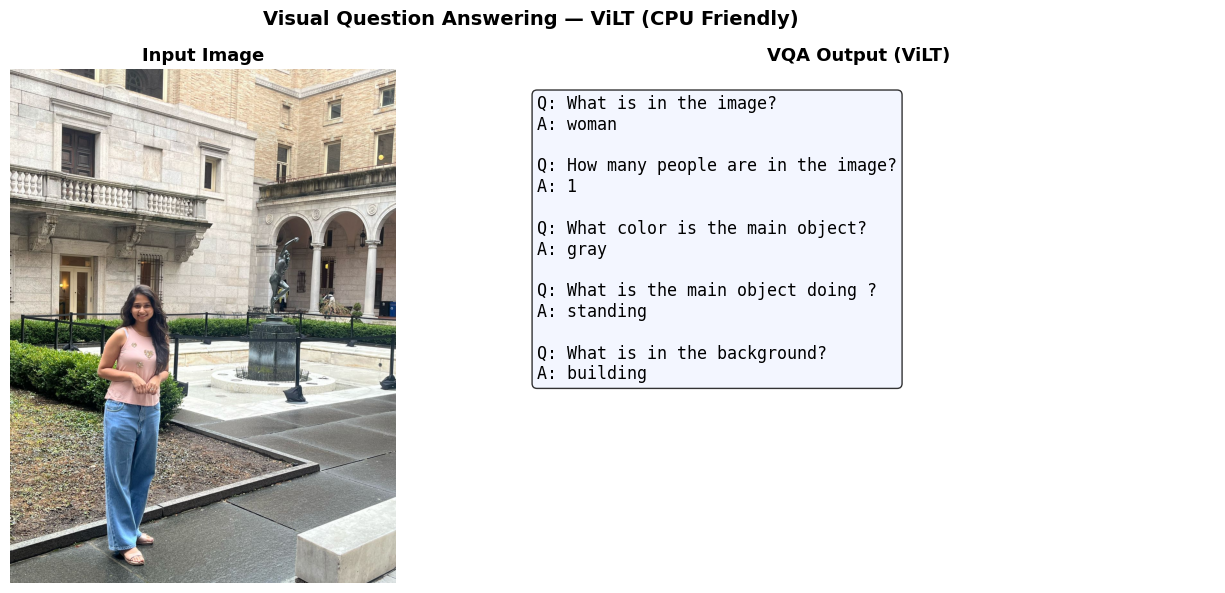

vqa_demo.png saved ✅


In [5]:
from PIL import Image
from google.colab import files
from io import BytesIO
import torch

# ViLT is very lightweight — works fine on CPU
from transformers import ViltProcessor, ViltForQuestionAnswering

print("Loading ViLT VQA model...")
processor  = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
vilt_model = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
vilt_model.eval()
print("ViLT loaded ✅")

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = Image.open(BytesIO(uploaded[filename])).convert("RGB")

# Ask questions
questions = [
    "What is in the image?",
    "How many people are in the image?",
    "What color is the main object?",
    "What is the main object doing ?",
    "What is in the background?",
]

print("\n── VQA Results ──────────────────────────────")
answers = []
for q in questions:
    inputs = processor(img, q, return_tensors="pt")
    with torch.no_grad():
        out    = vilt_model(**inputs)
        idx    = out.logits.argmax(-1).item()
        answer = vilt_model.config.id2label[idx]
    answers.append((q, answer))
    print(f"Q: {q}\nA: {answer}\n")

# Display
import matplotlib.pyplot as plt
fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(14, 6))
ax_img.imshow(img); ax_img.axis("off")
ax_img.set_title("Input Image", fontsize=13, fontweight="bold")

ax_txt.axis("off")
qa_text = "\n\n".join([f"Q: {q}\nA: {a}" for q, a in answers])
ax_txt.text(0.05, 0.95, qa_text, transform=ax_txt.transAxes,
            fontsize=12, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax_txt.set_title("VQA Output (ViLT)", fontsize=13, fontweight="bold")

plt.suptitle("Visual Question Answering — ViLT (CPU Friendly)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("vqa_demo.png", dpi=150)
plt.show()
print("vqa_demo.png saved ✅")